## Pandas analysis

This exercise consists in analyzing a dataset containg timing information from a series of Time-to-Digital-Converters (TDC) implemented in a couple of FPGAs (Field Programmable Gate Arrays). Each measurement (i.e. each row of the input file) consists of a flag that specifies the type of message ('HEAD', which in this case is always 1), two addresses of the TDC providing the signal ('FPGA' and 'TDC_CHANNEL'), and the timing information ('ORBIT_CNT', 'BX_COUNTER', and 'TDC_MEAS'). Each TDC count corresponds to 25/30 ns, whereas a unit of BX_COUNTER corresponds to 25 ns, and the ORBIT_CNT is increased every 'x' BX_COUNTER. This allows to store the time in a similar way to hours, minutes and seconds.

In [1]:
# If you didn't download it yet, please get the relevant file now!
#!wget https://www.dropbox.com/s/xvjzaxzz3ysphme/data_000637.txt -P ~/Documents/PoD/CP/LaboratoryOfComputationalPhysics_Y8/docs_06

1\. Create a Pandas DataFrame reading N rows of the 'data_000637.txt' dataset. Choose N to be smaller than or equal to the maximum number of rows and larger that 10k.

2\. Find out the number of BX in a ORBIT (the value 'x').

3\. Find out how much the data taking lasted. You can either make an estimate based on the fraction of the measurements (rows) you read, or perform this check precisely by reading out the whole dataset.

4\. Create a new column with the absolute time in ns (as a combination of the other three columns with timing information).

5\. Replace the values (all 1) of the HEAD column randomly with 0 or 1.

6\. Create a new DataFrame that contains only the rows with HEAD=1.

7\. Make two occupancy plots (one for each FPGA), i.e. plot the number of counts per TDC channel

8\. Use the groupby method to find out the noisy channels, i.e. the TDC channels with most counts (say the top 3)

9\. Count the number of unique orbits. Count the number of unique orbits with at least one measurement from TDC_CHANNEL=139

In [2]:
import pandas as pd
import numpy as np

#####  Solution 1
Create a Pandas DataFrame reading N rows of the 'data_000637.txt' dataset. 
Choose N to be smaller than or equal to the maximum number of rows and larger that 10k.

In [3]:
# # if we want to count the rows
# file = "docs_06/data_000637.txt"
# with open(file, "r") as f:
#     total_rows = sum(1 for i in f)

# # for i in f → recorre el archivo línea por línea.
# # 1 for i in f → por cada línea, produce un 1.
# # sum(...) → suma todos esos 1.

# print("Total rows:", total_rows)

In [4]:
df = pd.read_csv("data_000637.txt", nrows=15000)
df

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS
0,1,0,123,3869200167,2374,26
1,1,0,124,3869200167,2374,27
2,1,0,63,3869200167,2553,28
3,1,0,64,3869200167,2558,19
4,1,0,64,3869200167,2760,25
...,...,...,...,...,...,...
14995,1,1,4,3869200316,3399,9
14996,1,1,17,3869200316,3400,15
14997,1,1,10,3869200316,3530,16
14998,1,1,8,3869200316,3533,18


##### Solution 2
Find out the number of BX in a ORBIT (the value 'x').
a unit of BX_COUNTER corresponds to 25 ns, and the ORBIT_CNT is increased every 'x' BX_COUNTER

In [5]:
# First lets load the full dataframe
df = pd.read_csv("data_000637.txt")

# Then we find the maximum value for the column 'BX_COUNTER'
x = df['BX_COUNTER'].max()
print(x)

3563


The number of BX in a ORBIT (the value 'x') is actually 3564 because it takes value from 0 to 3563.

In [6]:
bx_per_orbit = ( df.groupby('ORBIT_CNT')['BX_COUNTER'].apply(lambda s: s.max() - s.min() + 1))
# de cada orbit se queda solo con la columna del BX y hacer max-min+1
bx_per_orbit.describe()

count    11001.000000
mean      2996.779929
std        625.867880
min          1.000000
25%       2868.000000
50%       3242.000000
75%       3402.000000
max       3564.000000
Name: BX_COUNTER, dtype: float64

#### Solution 3
how much the data taking lasted?

In [7]:
# vamos a multiplicar la cantidad de orbitas por el tiempo que toma cada una
number_of_orbits = df['ORBIT_CNT'].max() - df['ORBIT_CNT'].min() + 1
# print(number_of_orbits) # no es 11001 porque hay orbitas que no aparecen en el dataframe (no se registaron eventos en ese momento)
time_orbit_ns = 3564*25 # cada BX son 25 ns y hay 3564 BX en cada orbita
time_ns = number_of_orbits*time_orbit_ns
time_s = time_ns/10**9
print('Data takings lasted', time_ns, '[ns], that is', time_s, '[s]')

Data takings lasted 980545500 [ns], that is 0.9805455 [s]


#### Solution 4
Create a new column with the absolute time in ns (as a combination of the other three columns with timing information)

In [8]:
# ORBIT_CNT no es un tiempo, es un contador de órbitas.
# Para convertirlo en tiempo lo multiplicamos por la duración de una órbita.

df["TIME_ns"] = (
    df["TDC_MEAS"]*(25/30)
    + df["BX_COUNTER"]*25
    + df["ORBIT_CNT"]*3564*25 )

df["TIME_s"] = (
    (df["TDC_MEAS"]*(25/30)
    + df["BX_COUNTER"]*25
    + df["ORBIT_CNT"]*3564*25) / 10**9 )

df

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,TIME_ns,TIME_s
0,1,0,123,3869200167,2374,26,3.447457e+14,344745.734939
1,1,0,124,3869200167,2374,27,3.447457e+14,344745.734939
2,1,0,63,3869200167,2553,28,3.447457e+14,344745.734944
3,1,0,64,3869200167,2558,19,3.447457e+14,344745.734944
4,1,0,64,3869200167,2760,25,3.447457e+14,344745.734949
...,...,...,...,...,...,...,...,...
1310715,1,0,62,3869211171,762,14,3.447467e+14,344746.715355
1310716,1,1,4,3869211171,763,11,3.447467e+14,344746.715355
1310717,1,0,64,3869211171,764,0,3.447467e+14,344746.715355
1310718,1,0,139,3869211171,769,0,3.447467e+14,344746.715355


In [9]:
# Si el punto anterior quedo bien, la resta entre el primer y el último dato me debe dar el mismo valor que en el ejercicio anterior

time_check = df["TIME_s"].max() - df["TIME_s"].min()
print(time_check)

0.9804162533255294


#### Solution 5
Replace the values (all 1) of the HEAD column randomly with 0 or 1.

In [10]:
df["HEAD"] = np.random.choice([0,1], size=len(df))
df

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,TIME_ns,TIME_s
0,1,0,123,3869200167,2374,26,3.447457e+14,344745.734939
1,1,0,124,3869200167,2374,27,3.447457e+14,344745.734939
2,0,0,63,3869200167,2553,28,3.447457e+14,344745.734944
3,0,0,64,3869200167,2558,19,3.447457e+14,344745.734944
4,1,0,64,3869200167,2760,25,3.447457e+14,344745.734949
...,...,...,...,...,...,...,...,...
1310715,0,0,62,3869211171,762,14,3.447467e+14,344746.715355
1310716,1,1,4,3869211171,763,11,3.447467e+14,344746.715355
1310717,1,0,64,3869211171,764,0,3.447467e+14,344746.715355
1310718,0,0,139,3869211171,769,0,3.447467e+14,344746.715355


#### Solution 6
Create a new DataFrame that contains only the rows with HEAD=1.

In [11]:
new_df = df[df["HEAD"] == 1]
new_df.reset_index()

,index,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,TIME_ns,TIME_s
0,0,1,0,123,3869200167,2374,26,3.447457e+14,344745.734939
1,1,1,0,124,3869200167,2374,27,3.447457e+14,344745.734939
2,4,1,0,64,3869200167,2760,25,3.447457e+14,344745.734949
3,5,1,0,63,3869200167,2762,4,3.447457e+14,344745.734949
4,7,1,0,139,3869200167,2776,0,3.447457e+14,344745.734949
...,...,...,...,...,...,...,...,...,...
654996,1310711,1,1,39,3869211171,430,0,3.447467e+14,344746.715347
654997,1310712,1,1,35,3869211171,429,4,3.447467e+14,344746.715347
654998,1310713,1,0,64,3869211171,758,18,3.447467e+14,344746.715355
654999,1310716,1,1,4,3869211171,763,11,3.447467e+14,344746.715355


#### Solution 7
Make two occupancy plots (one for each FPGA), i.e. plot the number of counts per TDC channel

In [12]:
import matplotlib.pyplot as plt

# 1. Obtenemos la lista de FPGAs únicas 
fpgas = df['FPGA'].unique()
fpgas

array([0, 1])

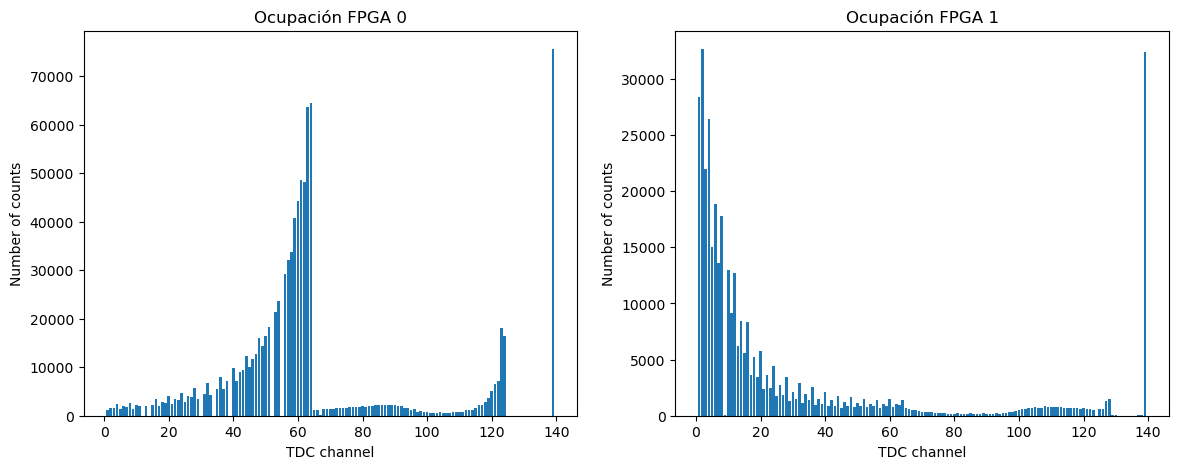

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

df_fpga0 = df[df['FPGA'] == 0]
# Contamos cuántas veces aparece cada canal en esa FPGA
counts0 = df_fpga0['TDC_CHANNEL'].value_counts() 
# el resultado al usar value_counts() es una serie
# donde el índice es el número del canal y el valor es la cantidad de lineas con ese número.
ax[0].bar(counts0.index, counts0.values)
ax[0].set_title("Ocupación FPGA 0")


df_fpga1 = df[df['FPGA'] == 1]
counts1 = df_fpga1['TDC_CHANNEL'].value_counts()
ax[1].bar(counts1.index, counts1.values)
ax[1].set_title("Ocupación FPGA 1")

# Etiquetas
for a in ax:
    a.set_xlabel("TDC channel")
    a.set_ylabel("Number of counts")

plt.show()

#### Solution 8
Use the groupby method to find out the noisy channels, i.e. the TDC channels with most counts (say the top 3)

In [14]:
# Agrupamos y contamos
noisy_channels = df.groupby(['FPGA', 'TDC_CHANNEL'])['HEAD'].count()

# Ordenamos de mayor a menor para ver los más ruidosos arriba
noisy_channels = noisy_channels.sort_values(ascending=False)

# 4. Mostramos los 3 primeros
print("Los 3 canales más ruidosos son:")
print(noisy_channels.head(3))

Los 3 canales más ruidosos son:
FPGA  TDC_CHANNEL
0     139            75617
      64             64581
      63             63724
Name: HEAD, dtype: int64


#### Solution 9
Count the number of unique orbits. Count the number of unique orbits with at least one measurement from TDC_CHANNEL=139

In [15]:
total_orbits = df['ORBIT_CNT'].nunique()
print(f"Número de órbitas únicas: {total_orbits}")

Número de órbitas únicas: 11001


In [16]:
# 1. Filtramos solo las filas del canal 139
df_139 = df[df['TDC_CHANNEL'] == 139]

# 2. De esas filas, contamos cuántas órbitas distintas hay
orbits_139 = df_139['ORBIT_CNT'].nunique()
print(f"Órbitas con actividad en el canal 139: {orbits_139}")

Órbitas con actividad en el canal 139: 10976
